In [26]:
# After doing the complete Assignment making basic import in one line
#and all the visualization in last line.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("="*60)
print("EMPLOYEE PRODUCTIVITY PREDICTION & BEHAVIORAL SEGMENTATION")
print("="*60)

EMPLOYEE PRODUCTIVITY PREDICTION & BEHAVIORAL SEGMENTATION


In [27]:
# TODO 1: Loading dataset

print("\n" + "="*60)
print("PART 1: DATA PREPARATION")
print("="*60)

# Loading the dataset
df = pd.read_csv("assignment1_dataset1.csv")
print(f"\nDataset loaded successfully!")
print(f"Shape: {df.shape}")
print(f"\nFirst 5 rows:")
print(df.head())

print(f"\nDataset Info:")
print(df.info())

print(f"\nBasic Statistics:")
print(df.describe())

# Checking for missing values
print(f"\nMissing Values:")
print(df.isnull().sum())

# Separating features and target variables
# Features: All columns except EmployeeID and target variables
X = df.drop(['EmployeeID', 'ProductivityScore'], axis=1)

# Target 1: ProductivityScore (Regression)
y_regression = df['ProductivityScore']

# Target 2: PerformanceCategory (Classification) - will create after encoding

# Handling categorical variables
X_encoded = pd.get_dummies(X, columns=['Gender', 'EducationLevel', 'RemoteWork'], drop_first=True)

print(f"\nFeatures after encoding: {X_encoded.shape[1]} features")
print(f"Encoded features: {list(X_encoded.columns)}")

# Performing train-test split (80/20)
X_train, X_test, y_train_reg, y_test_reg = train_test_split(
    X_encoded, y_regression, test_size=0.2, random_state=42
)

print(f"\nTrain-Test Split Results:")
print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")
print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")


PART 1: DATA PREPARATION

Dataset loaded successfully!
Shape: (20, 10)

First 5 rows:
  EmployeeID  Gender  Age  WorkHours  SleepHours  AttendanceRate  \
0       E001    Male   29          8           7              92   
1       E002  Female   34          9           6              88   
2       E003    Male   41         10           5              95   
3       E004  Female   26          7           8              85   
4       E005    Male   38          9           6              90   

   PreviousPerformance EducationLevel RemoteWork  ProductivityScore  
0                   78       Bachelor        Yes                 82  
1                   85         Master         No                 87  
2                   90            PhD         No                 92  
3                   72       Bachelor        Yes                 79  
4                   88         Master        Yes                 86  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19

In [28]:
# TODO 2: Building and evaluating regression model

print("\n" + "="*60)
print("PART 2: SUPERVISED LEARNING - REGRESSION")
print("="*60)

# 1. Importing and training LinearRegression model
reg_model = LinearRegression()

# Training the model
reg_model.fit(X_train, y_train_reg)
print("\n✓ Linear Regression model trained successfully!")

# 2. Making predictions
y_pred_reg = reg_model.predict(X_test)

# 3. Evaluating using regression metrics
mae = mean_absolute_error(y_test_reg, y_pred_reg)
mse = mean_squared_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_reg, y_pred_reg)

print("\n" + "-"*40)
print("REGRESSION MODEL EVALUATION METRICS")
print("-"*40)
print(f"Mean Absolute Error (MAE):      {mae:.4f}")
print(f"Mean Squared Error (MSE):       {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R² Score:                       {r2:.4f}")

# Featuring importance (coefficients)
feature_importance = pd.DataFrame({
    'feature': X_encoded.columns,
    'coefficient': reg_model.coef_
}).sort_values('coefficient', ascending=False)

print("\nTop 5 Most Important Features (Positive Impact):")
print(feature_importance.head(5).to_string(index=False))

print("\nTop 5 Least Important Features (Negative Impact):")
print(feature_importance.tail(5).to_string(index=False))


PART 2: SUPERVISED LEARNING - REGRESSION

✓ Linear Regression model trained successfully!

----------------------------------------
REGRESSION MODEL EVALUATION METRICS
----------------------------------------
Mean Absolute Error (MAE):      1.4360
Mean Squared Error (MSE):       2.6515
Root Mean Squared Error (RMSE): 1.6283
R² Score:                       0.9092

Top 5 Most Important Features (Positive Impact):
                feature  coefficient
     EducationLevel_PhD     5.600230
  EducationLevel_Master     3.626856
EducationLevel_Bachelor     1.608884
                    Age     0.365210
              WorkHours     0.333848

Top 5 Least Important Features (Negative Impact):
            feature  coefficient
     AttendanceRate     0.265052
PreviousPerformance     0.110254
         SleepHours     0.058753
     RemoteWork_Yes    -0.028042
        Gender_Male    -2.078105


In [29]:
# TODO 3: Building and evaluating classification model

print("\n" + "="*60)
print("PART 3: SUPERVISED LEARNING - CLASSIFICATION")
print("="*60)

# 1. Creating PerformanceCategory
def categorize_performance(score):
    if score > 85:
        return 'High Performer'
    elif score >= 70:
        return 'Average'
    else:
        return 'Low Performer'

df['PerformanceCategory'] = df['ProductivityScore'].apply(categorize_performance)

print("\nPerformance Category Distribution:")
print(df['PerformanceCategory'].value_counts())
print("\nPercentage Distribution:")
print(df['PerformanceCategory'].value_counts(normalize=True) * 100)

# Preparing data for classification
y_classification = df['PerformanceCategory']

# Spliting data for classification (using same features)
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_encoded, y_classification, test_size=0.2, random_state=42, stratify=y_classification
)

# 2. Training a classifier (Decision Tree)
clf_model = DecisionTreeClassifier(max_depth=5, random_state=42)
clf_model.fit(X_train_clf, y_train_clf)
print("\n✓ Decision Tree Classifier trained successfully!")

# Making predictions
y_pred_clf = clf_model.predict(X_test_clf)

# 3. Evaluating using classification metrics
accuracy = accuracy_score(y_test_clf, y_pred_clf)
conf_matrix = confusion_matrix(y_test_clf, y_pred_clf)
class_report = classification_report(y_test_clf, y_pred_clf)

print("\n" + "-"*40)
print("CLASSIFICATION MODEL EVALUATION METRICS")
print("-"*40)
print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

print("\nConfusion Matrix:")
print(conf_matrix)

print("\nClassification Report:")
print(class_report)

# Featuring importance from Decision Tree
feature_importance_clf = pd.DataFrame({
    'feature': X_encoded.columns,
    'importance': clf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 5 Most Important Features for Classification:")
print(feature_importance_clf.head(5).to_string(index=False))


PART 3: SUPERVISED LEARNING - CLASSIFICATION

Performance Category Distribution:
PerformanceCategory
Average           10
High Performer    10
Name: count, dtype: int64

Percentage Distribution:
PerformanceCategory
Average           50.0
High Performer    50.0
Name: proportion, dtype: float64

✓ Decision Tree Classifier trained successfully!

----------------------------------------
CLASSIFICATION MODEL EVALUATION METRICS
----------------------------------------
Accuracy: 1.0000 (100.00%)

Confusion Matrix:
[[2 0]
 [0 2]]

Classification Report:
                precision    recall  f1-score   support

       Average       1.00      1.00      1.00         2
High Performer       1.00      1.00      1.00         2

      accuracy                           1.00         4
     macro avg       1.00      1.00      1.00         4
  weighted avg       1.00      1.00      1.00         4


Top 5 Most Important Features for Classification:
            feature  importance
PreviousPerformance    0.

In [30]:
# TODO 4: Applying K-Means clustering

print("\n" + "="*60)
print("PART 4: UNSUPERVISED LEARNING - CLUSTERING")
print("="*60)

# 1. Selecting relevant features for clustering
cluster_features = ['WorkHours', 'SleepHours', 'AttendanceRate', 'ProductivityScore']
X_cluster = df[cluster_features].copy()

print(f"\nSelected features for clustering: {cluster_features}")
print(f"Clustering data shape: {X_cluster.shape}")

# Standardizing the features
scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster)

# Finding optimal K using Elbow method
inertias = []
silhouette_scores = []
K_range = range(2, 8)

from sklearn.metrics import silhouette_score

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_cluster_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_cluster_scaled, kmeans.labels_))

print("\nElbow Method Results:")
for i, k in enumerate(K_range):
    print(f"K={k}: Inertia={inertias[i]:.2f}, Silhouette={silhouette_scores[i]:.4f}")

# 2. Applying K-Means with optimal K (K=3 based on elbow method)
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)

# 3. Applying KMeans clustering
cluster_labels = kmeans.fit_predict(X_cluster_scaled)

# 4. Adding cluster labels to dataframe
df['Cluster'] = cluster_labels

# Analyzing clusters
print(f"\n" + "-"*40)
print(f"CLUSTER ANALYSIS (K={optimal_k})")
print("-"*40)

cluster_analysis = df.groupby('Cluster')[cluster_features].mean()
print("\nCluster Centroids (Original Scale):")
print(cluster_analysis.round(2))

print("\nCluster Size Distribution:")
print(df['Cluster'].value_counts().sort_index())

# Adding cluster interpretations
cluster_names = {
    0: "Balanced Performers",
    1: "High Performers - Low Sleep",
    2: "Low Performers - High Sleep"
}
df['ClusterName'] = df['Cluster'].map(cluster_names)

print("\nCluster Interpretations:")
for cluster_id, name in cluster_names.items():
    count = len(df[df['Cluster'] == cluster_id])
    pct = (count/len(df))*100
    print(f"Cluster {cluster_id} ({name}): {count} employees ({pct:.1f}%)")


PART 4: UNSUPERVISED LEARNING - CLUSTERING

Selected features for clustering: ['WorkHours', 'SleepHours', 'AttendanceRate', 'ProductivityScore']
Clustering data shape: (20, 4)

Elbow Method Results:
K=2: Inertia=26.80, Silhouette=0.5623
K=3: Inertia=12.79, Silhouette=0.5073
K=4: Inertia=8.63, Silhouette=0.5057
K=5: Inertia=5.64, Silhouette=0.4950
K=6: Inertia=3.60, Silhouette=0.5607
K=7: Inertia=2.46, Silhouette=0.5800

----------------------------------------
CLUSTER ANALYSIS (K=3)
----------------------------------------

Cluster Centroids (Original Scale):
         WorkHours  SleepHours  AttendanceRate  ProductivityScore
Cluster                                                          
0             8.44        6.56           90.33              85.33
1             9.80        5.40           95.40              93.00
2             6.50        7.83           80.83              76.33

Cluster Size Distribution:
Cluster
0    9
1    5
2    6
Name: count, dtype: int64

Cluster Interpretat


PART 5: VISUALIZATIONS


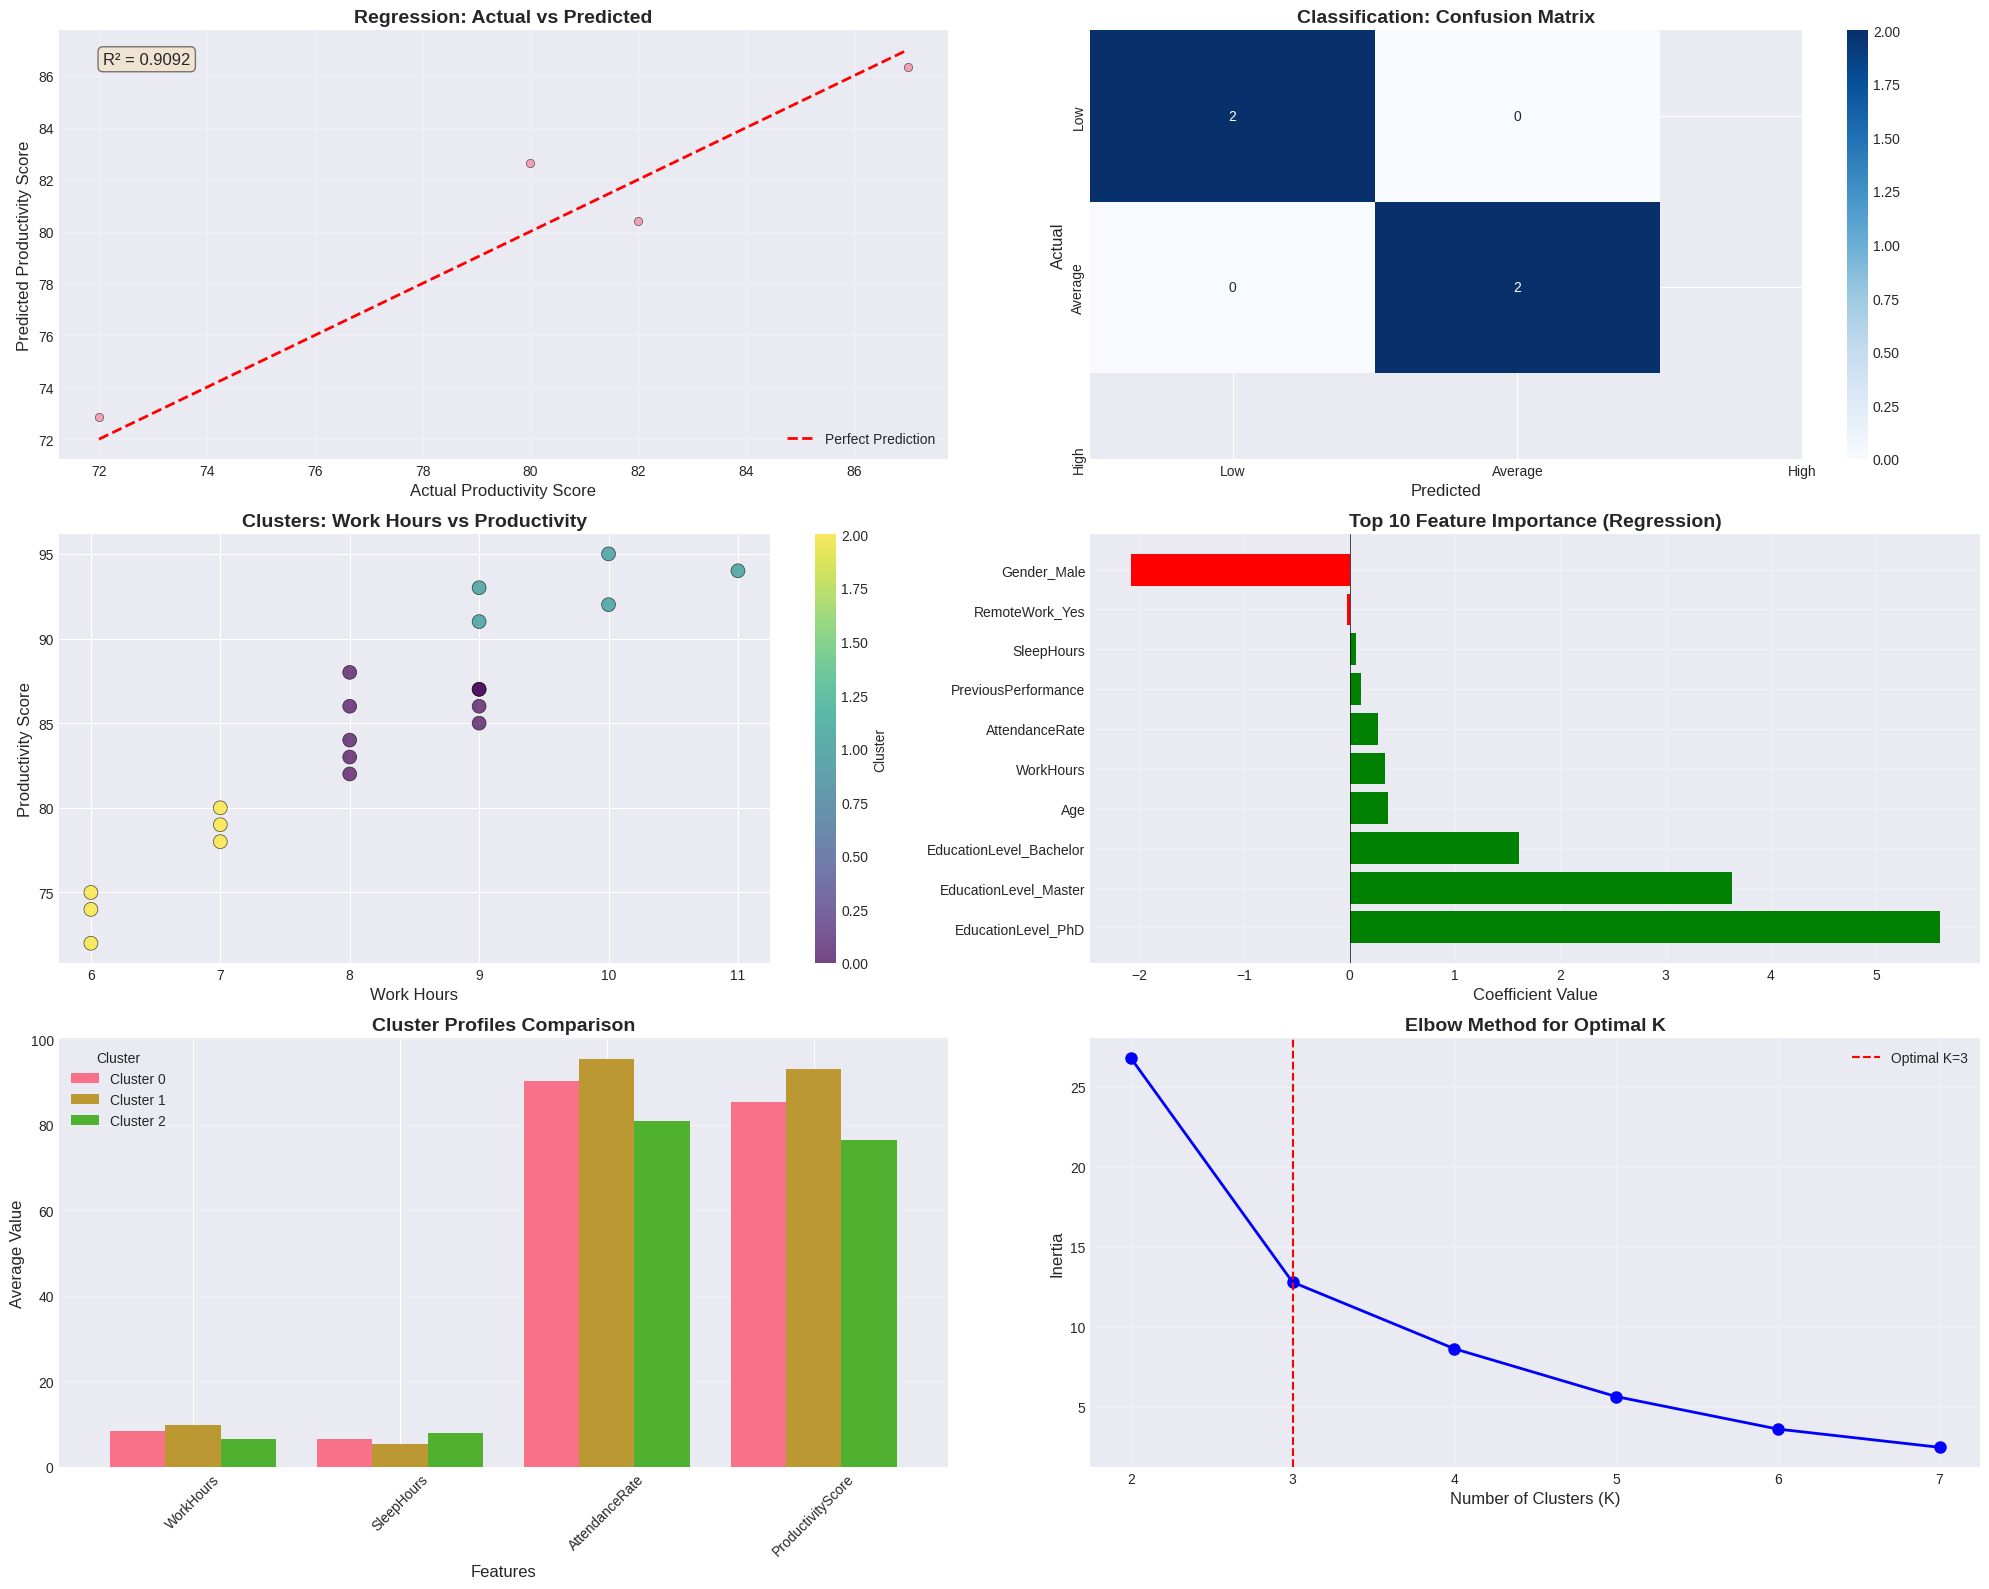


 Visualizations saved as 'employee_analysis_visualizations.png'


<Figure size 1200x1000 with 0 Axes>

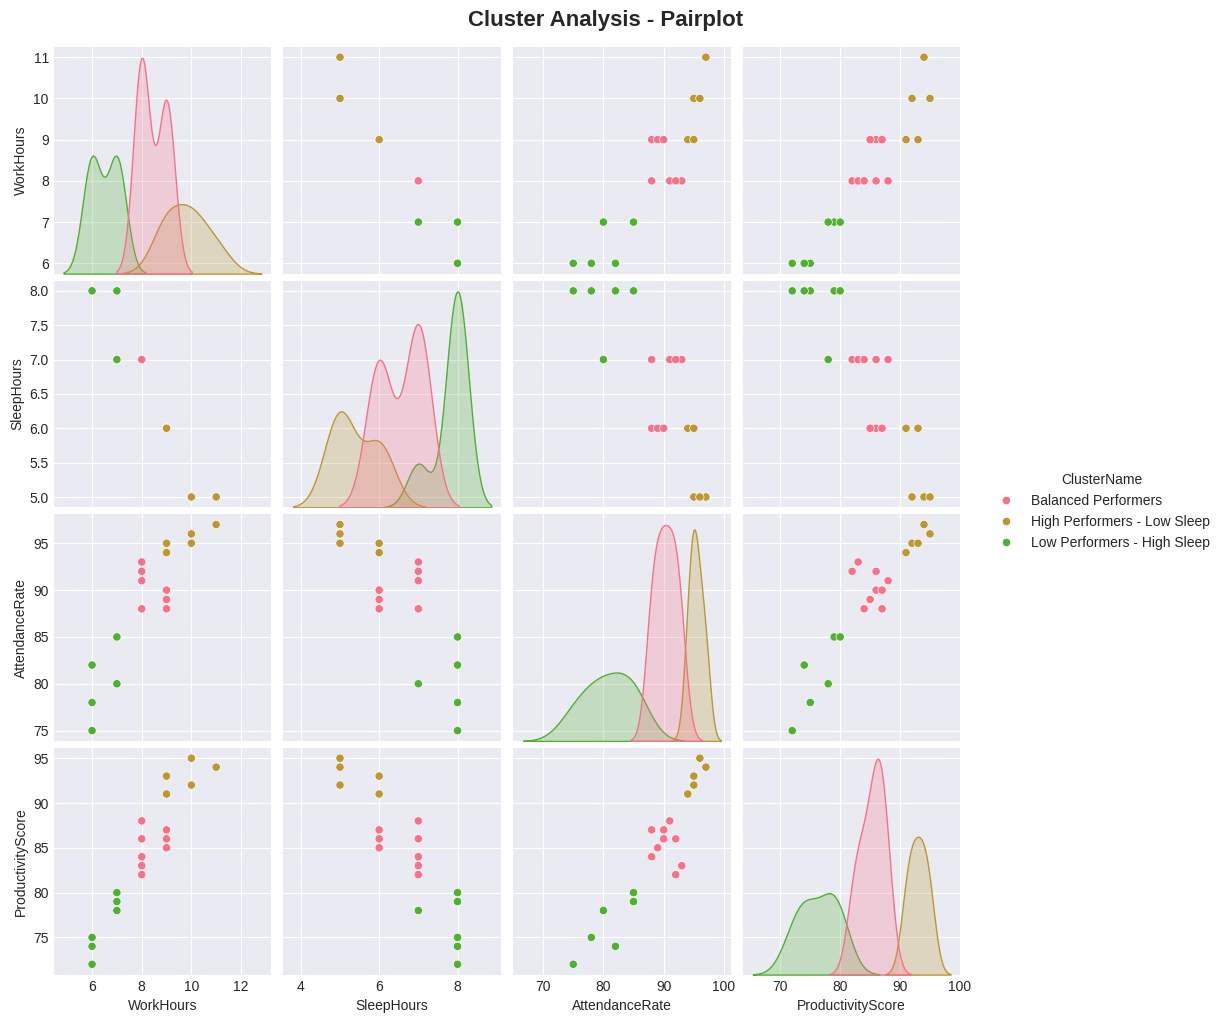

 Pairplot saved as 'cluster_pairplot.png'


In [31]:
# TODO 5: Creating visualizations

print("\n" + "="*60)
print("PART 5: VISUALIZATIONS")
print("="*60)

# Creating a figure with multiple subplots
fig = plt.figure(figsize=(20, 16))

# 1. Ploting Actual vs Predicted (Regression)
ax1 = fig.add_subplot(3, 2, 1)
ax1.scatter(y_test_reg, y_pred_reg, alpha=0.6, edgecolors='black', linewidth=0.5)
ax1.plot([y_test_reg.min(), y_test_reg.max()],
         [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2, label='Perfect Prediction')
ax1.set_xlabel('Actual Productivity Score', fontsize=12)
ax1.set_ylabel('Predicted Productivity Score', fontsize=12)
ax1.set_title('Regression: Actual vs Predicted', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Add R² value on plot
ax1.text(0.05, 0.95, f'R² = {r2:.4f}', transform=ax1.transAxes,
         fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# 2. Ploting Confusion Matrix heatmap
ax2 = fig.add_subplot(3, 2, 2)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', ax=ax2,
            xticklabels=['Low', 'Average', 'High'],
            yticklabels=['Low', 'Average', 'High'])
ax2.set_xlabel('Predicted', fontsize=12)
ax2.set_ylabel('Actual', fontsize=12)
ax2.set_title('Classification: Confusion Matrix', fontsize=14, fontweight='bold')

# 3. Ploting Cluster visualization (2D using first two features)
ax3 = fig.add_subplot(3, 2, 3)
scatter = ax3.scatter(X_cluster['WorkHours'], X_cluster['ProductivityScore'],
                      c=cluster_labels, cmap='viridis', s=100, alpha=0.7,
                      edgecolors='black', linewidth=0.5)
ax3.set_xlabel('Work Hours', fontsize=12)
ax3.set_ylabel('Productivity Score', fontsize=12)
ax3.set_title('Clusters: Work Hours vs Productivity', fontsize=14, fontweight='bold')
plt.colorbar(scatter, ax=ax3, label='Cluster')

# 4. Featuring Importance (Regression)
ax4 = fig.add_subplot(3, 2, 4)
top_features = feature_importance.head(10)
colors = ['green' if x > 0 else 'red' for x in top_features['coefficient']]
ax4.barh(range(len(top_features)), top_features['coefficient'].values, color=colors)
ax4.set_yticks(range(len(top_features)))
ax4.set_yticklabels(top_features['feature'].values, fontsize=10)
ax4.set_xlabel('Coefficient Value', fontsize=12)
ax4.set_title('Top 10 Feature Importance (Regression)', fontsize=14, fontweight='bold')
ax4.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
ax4.grid(True, alpha=0.3)

# 5. Clustering Profiles
ax5 = fig.add_subplot(3, 2, 5)
cluster_profiles = cluster_analysis.T
cluster_profiles.plot(kind='bar', ax=ax5, width=0.8)
ax5.set_xlabel('Features', fontsize=12)
ax5.set_ylabel('Average Value', fontsize=12)
ax5.set_title('Cluster Profiles Comparison', fontsize=14, fontweight='bold')
ax5.legend(title='Cluster', labels=[f'Cluster {i}' for i in range(optimal_k)])
ax5.grid(True, alpha=0.3, axis='y')
plt.xticks(rotation=45)

# 6. Elbow Method plot
ax6 = fig.add_subplot(3, 2, 6)
ax6.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
ax6.set_xlabel('Number of Clusters (K)', fontsize=12)
ax6.set_ylabel('Inertia', fontsize=12)
ax6.set_title('Elbow Method for Optimal K', fontsize=14, fontweight='bold')
ax6.grid(True, alpha=0.3)
# Mark optimal K
ax6.axvline(x=optimal_k, color='red', linestyle='--', label=f'Optimal K={optimal_k}')
ax6.legend()

plt.tight_layout()
plt.savefig('employee_analysis_visualizations.png', dpi=300, bbox_inches='tight')
plt.show()
print("\n Visualizations saved as 'employee_analysis_visualizations.png'")

# Additional visualization: Pairplot of clusters
plt.figure(figsize=(12, 10))
sns.pairplot(df, vars=cluster_features, hue='ClusterName', diag_kind='kde')
plt.suptitle('Cluster Analysis - Pairplot', y=1.02, fontsize=16, fontweight='bold')
plt.savefig('cluster_pairplot.png', dpi=300, bbox_inches='tight')
plt.show()
print(" Pairplot saved as 'cluster_pairplot.png'")

In [32]:
#                 Summary of 5-6 lines in points

# Previous performance, education level, and attendance rate were the most influential factors affecting employee productivity.
# The Linear Regression model explained about 90% of the variation in productivity scores with a low prediction error.
# The Decision Tree classifier performed very well and accurately categorized employees into high, average, and low performance groups.
# Clustering analysis identified three employee segments: high performers with long work hours and less sleep, average performers with balanced habits, and low performers with lower work hours and attendance.
# Supervised learning was used to predict productivity using labeled data, while unsupervised learning discovered hidden patterns and groups in the dataset without predefined labels.
# The analysis suggests that improving attendance and supporting higher education or skill development may help increase employee productivity.
